In [1]:
from pathlib import Path
import sys
import numpy as np
import torch

In [5]:
p1 = Path.cwd().parent

utils_dir = p1 / "src/utils"

# Make sure it exists (optional but recommended)
if not utils_dir.is_dir():
    raise FileNotFoundError(f"Folder not found: {utils_dir}")

# Add CSDI to Python import path so imports work from anywhere
sys.path.insert(0, str(utils_dir))

In [7]:
from WIP_SDE import *

In [8]:
# assuming GBMLogSDE and SigmaSchedule are in scope / imported
def test_gbm_log_marginal(
    schedule="exponential",
    sigma_min=0.01,
    sigma_max=1.0,
    t_value=0.73,
    B=20000,
    L=64,
    seed=0,
):
    torch.manual_seed(seed)

    sde = GBMLogSDE(sigma_min=sigma_min, sigma_max=sigma_max, schedule=schedule, N=1000)

    # Toy x0: deterministic waveform so we don't confuse variance from x0 vs added noise
    idx = torch.linspace(0, 2*np.pi, L)
    x0 = torch.sin(idx)[None, :].repeat(B, 1)  # (B, L)

    t = torch.full((B,), float(t_value), dtype=torch.float32)

    xt, _ = perturb_x0(sde, x0, t)
    delta = (xt - x0).reshape(-1)  # all dims pooled

    # empirical stats
    mean_emp = delta.mean().item()
    std_emp = delta.std(unbiased=True).item()

    # theoretical
    sigma_th = float(sde.sigma_t(torch.tensor([t_value])).item())

    print(f"schedule={schedule}, t={t_value}")
    print(f"empirical mean(delta) = {mean_emp:.5f}  (should be ~0)")
    print(f"empirical std(delta)  = {std_emp:.5f}")
    print(f"theoretical sigma(t)  = {sigma_th:.5f}")
    print(f"ratio std_emp/sigma_th = {std_emp/sigma_th:.4f}  (should be ~1)")

test_gbm_log_marginal(schedule="linear", t_value=0.8)
test_gbm_log_marginal(schedule="exponential", t_value=0.8)
test_gbm_log_marginal(schedule="cosine", t_value=0.8)

schedule=linear, t=0.8
empirical mean(delta) = -0.00082  (should be ~0)
empirical std(delta)  = 0.80166
theoretical sigma(t)  = 0.80200
ratio std_emp/sigma_th = 0.9996  (should be ~1)
schedule=exponential, t=0.8
empirical mean(delta) = -0.00041  (should be ~0)
empirical std(delta)  = 0.39794
theoretical sigma(t)  = 0.39811
ratio std_emp/sigma_th = 0.9996  (should be ~1)
schedule=cosine, t=0.8
empirical mean(delta) = -0.00092  (should be ~0)
empirical std(delta)  = 0.90508
theoretical sigma(t)  = 0.90546
ratio std_emp/sigma_th = 0.9996  (should be ~1)


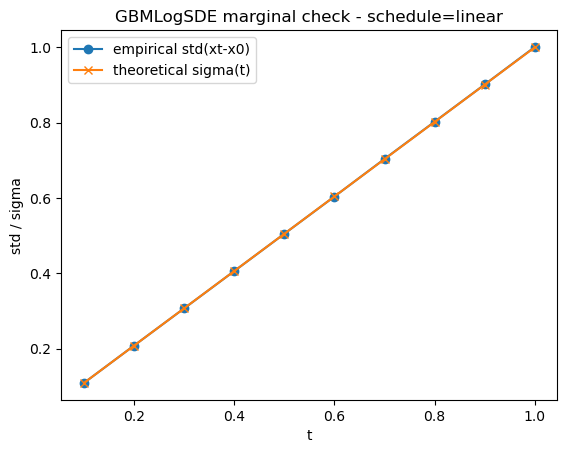

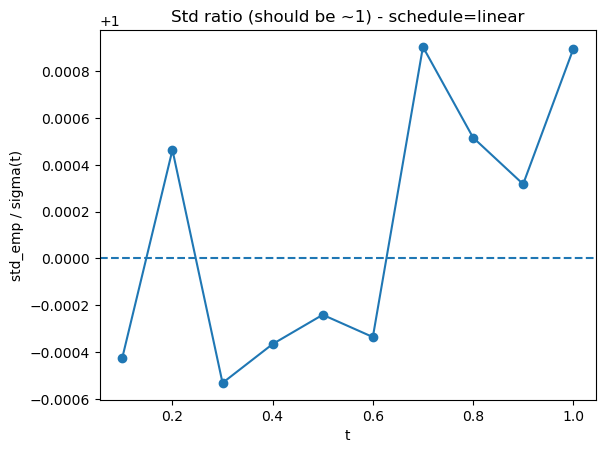

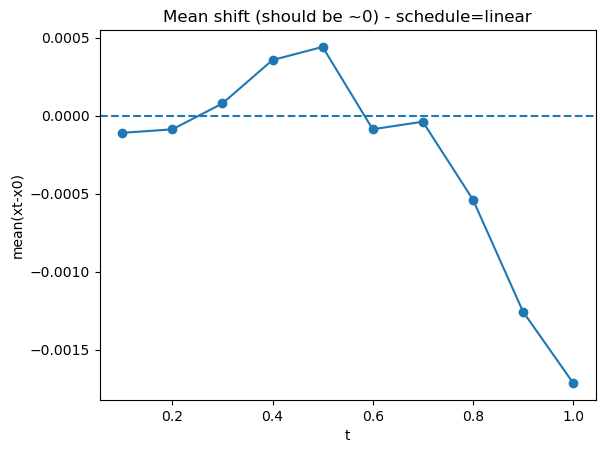

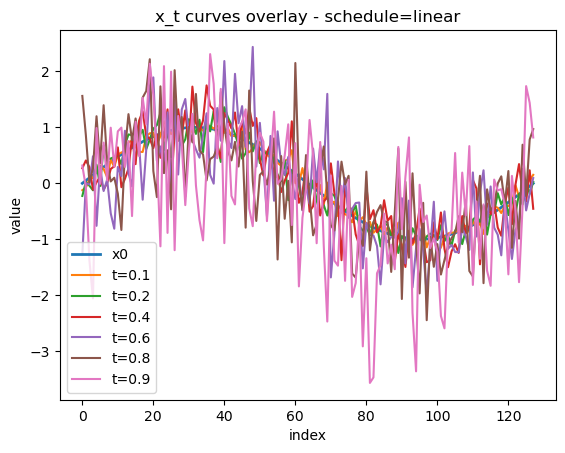

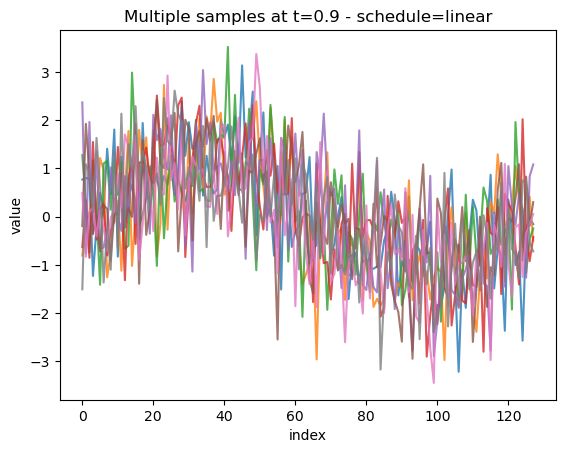

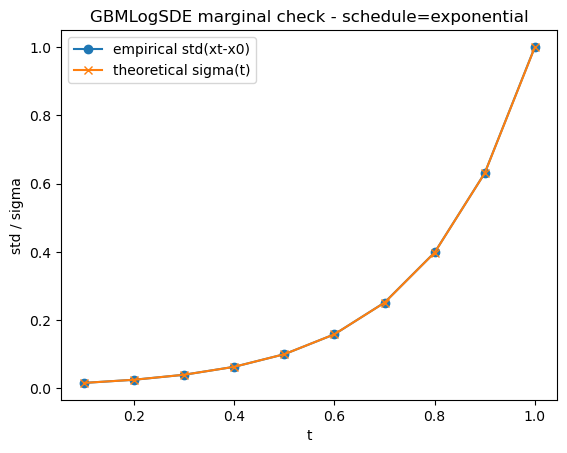

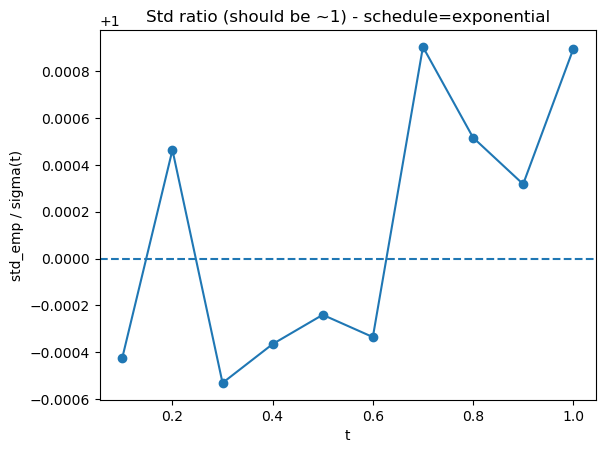

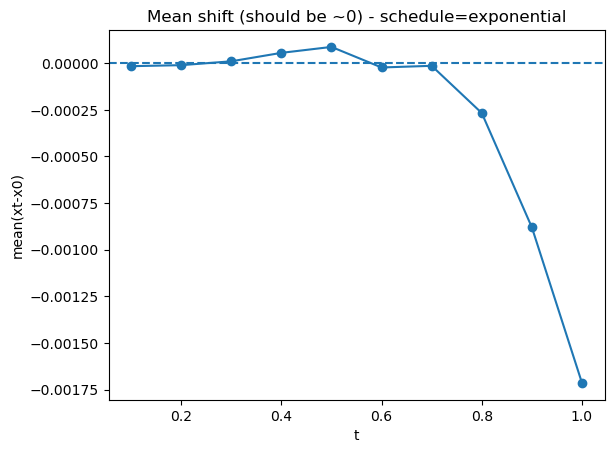

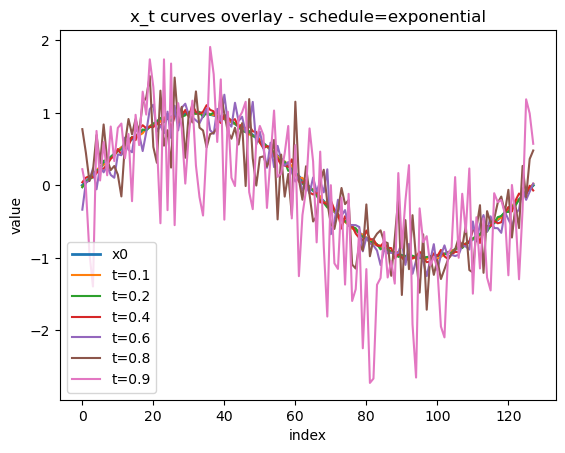

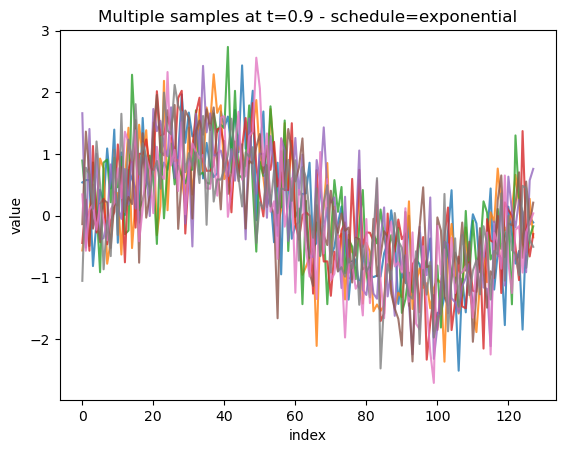

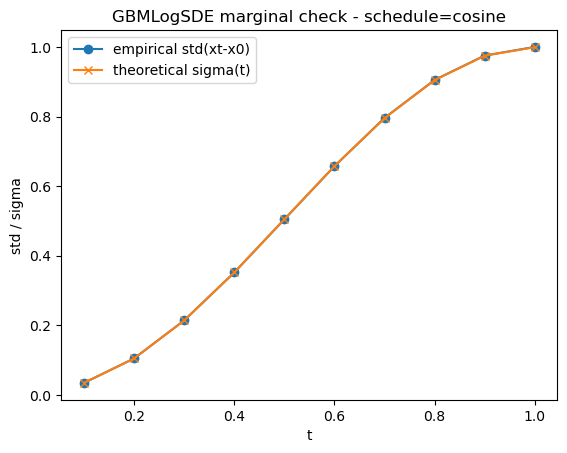

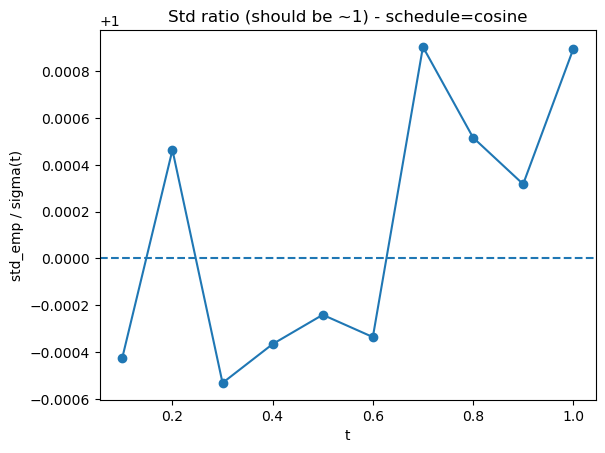

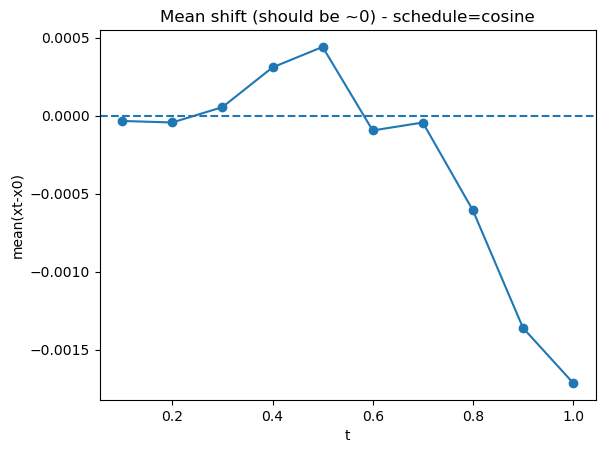

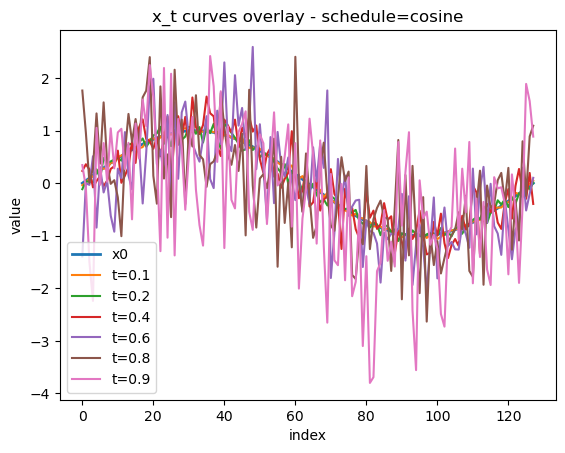

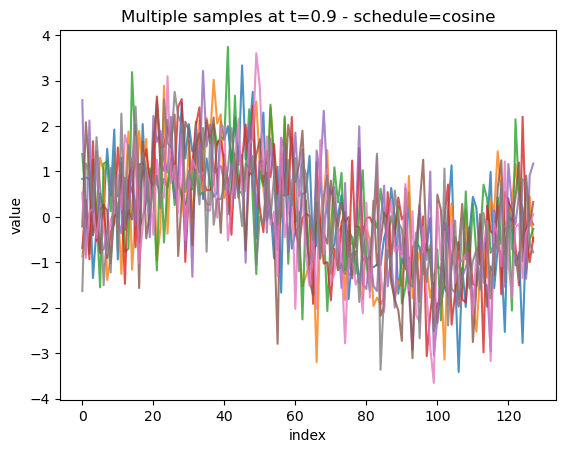

In [ ]:
import matplotlib.pyplot as plt

def gbm_marginal_sweep_plot(
    schedule="exponential",
    sigma_min=0.01,
    sigma_max=1.0,
    t_grid=None,          # e.g. np.arange(0.1, 1.01, 0.1)
    B=20000,
    L=64,
    seed=0,
):
    torch.manual_seed(seed)

    if t_grid is None:
        t_grid = np.arange(0.1, 1.01, 0.1)

    sde = GBMLogSDE(sigma_min=sigma_min, sigma_max=sigma_max, schedule=schedule, N=1000)

    # deterministic x0 waveform
    idx = torch.linspace(0, 2*np.pi, L)
    x0 = torch.sin(idx)[None, :].repeat(B, 1)  # (B, L)

    emp_std = []
    emp_mean = []
    th_sigma = []

    for tv in t_grid:
        t = torch.full((B,), float(tv), dtype=torch.float32)
        xt, _ = perturb_x0(sde, x0, t)
        # computing the added noise
        delta = (xt - x0).reshape(-1)

        emp_mean.append(delta.mean().item())
        emp_std.append(delta.std(unbiased=True).item())
        th_sigma.append(float(sde.sigma_t(torch.tensor([float(tv)])).item()))

    emp_std = np.array(emp_std)
    emp_mean = np.array(emp_mean)
    th_sigma = np.array(th_sigma)

    # Plot: empirical std vs theoretical sigma(t)
    plt.figure()
    plt.plot(t_grid, emp_std, marker="o", label="empirical std(xt-x0)")
    plt.plot(t_grid, th_sigma, marker="x", label="theoretical sigma(t)")
    plt.xlabel("t")
    plt.ylabel("std / sigma")
    plt.title(f"GBMLogSDE marginal check - schedule={schedule}")
    plt.legend()
    plt.show()

    # Plot: ratio
    plt.figure()
    plt.plot(t_grid, emp_std / th_sigma, marker="o")
    plt.axhline(1.0, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("std_emp / sigma(t)")
    plt.title(f"Std ratio (should be ~1) - schedule={schedule}")
    plt.show()

    # Plot: mean (should be ~0)
    plt.figure()
    plt.plot(t_grid, emp_mean, marker="o")
    plt.axhline(0.0, linestyle="--")
    plt.xlabel("t")
    plt.ylabel("mean(xt-x0)")
    plt.title(f"Mean shift (should be ~0) - schedule={schedule}")
    plt.show()


def gbm_visual_xt_curves(
    schedule="exponential",
    sigma_min=0.01,
    sigma_max=1.0,
    t_grid=None,          # e.g. [0.1,0.2,...]
    L=128,
    B=8,                  # few samples for visualization
    seed=0,
):
    torch.manual_seed(seed)

    if t_grid is None:
        t_grid = [0.1, 0.3, 0.5, 0.7, 0.9]

    sde = GBMLogSDE(sigma_min=sigma_min, sigma_max=sigma_max, schedule=schedule, N=1000)

    idx = torch.linspace(0, 2*np.pi, L)
    x0 = torch.sin(idx)[None, :].repeat(B, 1)  # (B, L)

    # pick one sample to overlay
    b0 = 0
    x_axis = np.arange(L)

    plt.figure()
    plt.plot(x_axis, x0[b0].cpu().numpy(), linewidth=2, label="x0")

    for tv in t_grid:
        t = torch.full((B,), float(tv), dtype=torch.float32)
        xt, _ = perturb_x0(sde, x0, t)
        plt.plot(x_axis, xt[b0].cpu().numpy(), label=f"t={tv:.1f}")

    plt.xlabel("index")
    plt.ylabel("value")
    plt.title(f"x_t curves overlay - schedule={schedule}")
    plt.legend()
    plt.show()

    # Optional: show multiple samples as separate figures for one t
    tv = float(t_grid[-1])
    t = torch.full((B,), tv, dtype=torch.float32)
    xt, _ = perturb_x0(sde, x0, t)

    plt.figure()
    for b in range(B):
        plt.plot(x_axis, xt[b].cpu().numpy(), alpha=0.8)
    plt.xlabel("index")
    plt.ylabel("value")
    plt.title(f"Multiple samples at t={tv:.1f} - schedule={schedule}")
    plt.show()


# Example usage:
t_grid = np.arange(0.1, 1.01, 0.1)

for sched in ["linear", "exponential", "cosine"]:
    gbm_marginal_sweep_plot(schedule=sched, t_grid=t_grid, B=20000, L=64, seed=0)
    gbm_visual_xt_curves(schedule=sched, t_grid=[0.1,0.2,0.4,0.6,0.8,0.9], L=128, B=8, seed=0)